<h1><b>Medical Data Visualizer</b></h1>
<p>By Shabri Chairul Akmal</p>

<hr/>

<h2><b>Project Overview</b></h2>
<p style="text-align: justify;">This project analyzes and visualizes medical examination data to explore the relationships between various health indicators and cardiovascular disease. Using Python with <b>Pandas</b>, <b>Matplotlib</b>, and <b>Seaborn</b>. Create <b>categorical plots</b> and <b>correlation heatmaps</b> to identify patterns in the data.</p>

<hr/>

<h2><b>Dataset Description</b></h2>
<p>The dataset from UCI contains medical examination records with the following features:</p>
<ul>
  <li><b>id</b>: Patient identifier</li>
  <li><b>age</b>: Age in days</li>
  <li><b>gender</b>: Gender (1 = female, 2 = male)</li>
  <li><b>height</b>: Height in cm</li>
  <li><b>weight</b>: Weight in kg</li>
  <li><b>ap_hi</b>: Systolic blood pressure</li>
  <li><b>ap_lo</b>: Diastolic blood pressure</li>
  <li><b>cholesterol</b>: Cholesterol level (1 = normal, 2 = above normal, 3 = well above normal)</li>
  <li><b>gluc</b>: Glucose level (1 = normal, 2 = above normal, 3 = well above normal)</li>
  <li><b>smoke</b>: Smoking status (0 = no, 1 = yes)</li>
  <li><b>alco</b>: Alcohol consumption (0 = no, 1 = yes)</li>
  <li><b>active</b>: Physical activity (0 = no, 1 = yes)</li>
  <li><b>cardio</b>: Cardiovascular disease (0 = no, 1 = yes)</li>
</ul>

<hr/>

<h2><b>Problem Statement</b></h2>
<p style="text-align: justify;">The task is to analyze this medical dataset to understand the factors that contribute to cardiovascular disease. We need to:</p>
<ol>
  <li><b>Create a categorical plot</b> showing the distribution of various health indicators (cholesterol, glucose, smoking, alcohol, physical activity, and overweight) segmented by cardiovascular disease presence.</li>
  <li><b>Create a correlation heatmap</b> to visualize relationships between all numerical features in the dataset after cleaning.</li>
</ol>

<hr/>

<h2><b>Solution Strategy</b></h2>

<h3>Part 1: Data Preparation</h3>
<ol>
  <li><b>Import Libraries</b>: Load Pandas, NumPy, Matplotlib, and Seaborn.</li>
  <li><b>Import Data</b>: Read the CSV file into a DataFrame.</li>
  <li><b>Add Overweight Column</b>: Calculate BMI (weight/height² in meters) and mark as 1 if BMI > 25.</li>
  <li><b>Normalize Data</b>: Convert cholesterol and glucose values to binary (0 = normal, 1 = above normal).</li>
</ol>

<h3>Part 2: Categorical Plot</h3>
<ol>
  <li><b>Melt Data</b>: Use <code>pd.melt()</code> to reshape the data for categorical plotting.</li>
  <li><b>Group Data</b>: Group by cardio status, feature, and value to count occurrences.</li>
  <li><b>Create Plot</b>: Use <code>sns.catplot()</code> to create bar charts for each feature, split by cardio presence.</li>
  <li><b>Save Figure</b>: Save the plot as 'catplot.png'.</li>
</ol>

<h3>Part 3: Correlation Heatmap</h3>
<ol>
  <li><b>Clean Data</b>: Filter out incorrect data (diastolic > systolic <code>df['ap_lo'] > df['ap_hi']</code> , height and weight outliers).</li>
  <li><b>Calculate Correlation</b>: Compute correlation matrix for all numerical columns.</li>
  <li><b>Create Mask</b>: Generate a mask for the upper triangle to avoid redundancy.</li>
  <li><b>Plot Heatmap</b>: Use <code>sns.heatmap()</code> with annotations and proper formatting.</li>
  <li><b>Save Figure</b>: Save the heatmap as 'heatmap.png'.</li>
</ol>

<hr/>

<h2><b>Implementation</b></h2>

<h3>Cell 1: Import Libraries</h3>


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#%pip install seaborn

<h3>Cell 2: Import Data</h3>

In [3]:
url="https://shabriakmal.github.io/Data-Analysis-python-freeCodeCamp/Medical_Data_Visualizer/medical_examination.csv"
df = pd.read_csv(url)

print(f"📊 Dataset loaded successfully!")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print("\nFirst 5 rows:")
display(df.head())

📊 Dataset loaded successfully!
Rows: 70,000
Columns: 13

First 5 rows:


,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


<h3>Cell 3: Add Overweight Column</h3>

In [4]:
# Add 'overweight' column
# BMI = weight / (height in meters)^2
# 1 if BMI > 25, else 0
df['overweight'] = (df['weight'] / (df['height'] / 100)**2).apply(lambda x: 0 if x < 25 else 1)

print("✅ Overweight column added successfully!")
print(f"\nOverweight distribution:")
print(df['overweight'].value_counts())

✅ Overweight column added successfully!

Overweight distribution:
overweight
1    43560
0    26440
Name: count, dtype: int64


<h3>Cell 4: Normalize Data</h3>

In [5]:
# Normalize data by making 0 always good and 1 always bad
# If cholesterol or gluc is 1, make it 0. If >1, make it 1.
df['cholesterol'] = df['cholesterol'].apply(lambda x: 0 if x==1 else 1 if x > 1 else x)
df['gluc'] = df['gluc'].apply(lambda x: 0 if x==1 else 1 if x > 1 else x)

print("✅ Data normalized successfully!")
print("\nCholesterol distribution after normalization:")
print(df['cholesterol'].value_counts())
print("\nGlucose distribution after normalization:")
print(df['gluc'].value_counts())

✅ Data normalized successfully!

Cholesterol distribution after normalization:
cholesterol
0    52385
1    17615
Name: count, dtype: int64

Glucose distribution after normalization:
gluc
0    59479
1    10521
Name: count, dtype: int64


<h3>Cell 5: Draw Categorical Plot</h3>

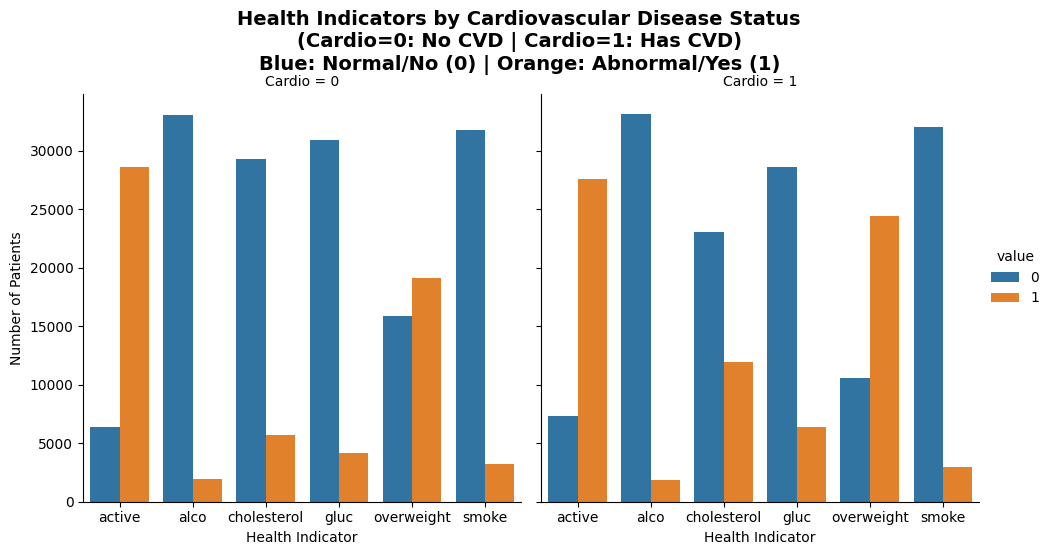

In [6]:
def draw_cat_plot():
    # Create DataFrame for cat plot using pd.melt
    df_cat = pd.melt(df,
                     id_vars='cardio',
                     value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight'])

    # Group and reformat data
    df_cat = df_cat.groupby(['cardio', 'variable', 'value']).size().reset_index()
    df_cat = df_cat.rename(columns={0: 'total'})

    # Create categorical plot
    graph = sns.catplot(data=df_cat,
                        kind='bar',
                        x='variable',
                        y='total',
                        hue='value',
                        col='cardio')

    # Add comprehensive title with explanations
    graph.fig.suptitle(
        'Health Indicators by Cardiovascular Disease Status\n'
        '(Cardio=0: No CVD | Cardio=1: Has CVD)\n'
        'Blue: Normal/No (0) | Orange: Abnormal/Yes (1)',
        fontsize=14,
        fontweight='bold',
        y=1.1
    )

    # Add axis labels
    graph.set_axis_labels("Health Indicator", "Number of Patients")

    # Set column titles
    graph.set_titles(col_template="Cardio = {col_name}")

    # Get figure
    fig = graph.fig

    # Save figure
    fig.savefig('catplot.png')

    return fig

# Call the function
fig_cat = draw_cat_plot()
plt.show()

<hr/>
<h2><b>Categorical Plot Interpretation</b></h2>

<p style="text-align: justify;">
  Compare two plots: <strong>left (cardio=0)</strong> = no disease,
  <strong>right (cardio=1)</strong> = with disease.
  Focus on the risk factor proportion for each condition.
</p>

<p style="text-align: justify;">
  Calculation:
  <code>risk = orange bars / (orange bars + blue bars)</code>.
  Since total counts are nearly identical between cases, simply compare the
  <strong>number of orange bars</strong> directly.
</p>

<hr/>

<h3>Visual Interpretation (Based on Plot Observation)</h3>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse:collapse; text-align:left;">
  <tr style="background:#f0f0f0;">
    <th>Risk Factor</th>
    <th>Observation (Approximate Values)</th>
  </tr>
  <tr>
    <td><strong>Active</strong></td>
    <td>Orange bars appear similar (~28,600 vs ~27,600) — no visible difference</td>
  </tr>
  <tr>
    <td><strong>Alcohol</strong></td>
    <td>Orange bars appear similar (~1,900 vs ~1,800) — negligible difference</td>
  </tr>
  <tr>
    <td><strong>Cholesterol</strong></td>
    <td style="color:red;"> <strong>Orange bar noticeably taller in disease group (~5,700 vs ~11,900) → appears to be a strong risk factor</strong></td>
  </tr>
  <tr>
    <td><strong>Glucose</strong></td>
    <td>Orange bar slightly taller in disease group (~4,100 vs ~6,400) → possible moderate risk factor</td>
  </tr>
  <tr>
    <td><strong>Overweight</strong></td>
    <td>Orange bar visibly taller in disease group (~19,100 vs ~24,400) → appears to be a notable risk factor</td>
  </tr>
  <tr>
    <td><strong>Smoke</strong></td>
    <td>Orange bars appear similar (~3,200 vs ~2,900) — no visible difference</td>
  </tr>
</table>

<p style="text-align: justify; margin-top:16px;">
  <strong>Conclusion:</strong>
  <span style="background:#fff3cd; padding:2px 8px;">
    Based on visual inspection, <strong>high cholesterol</strong> shows the most pronounced difference between groups
    (approximately double in the disease group), followed by <strong>overweight</strong> and <strong>elevated glucose</strong>.
    Physical activity, alcohol consumption, and smoking appear to have
    <strong>minimal visual difference</strong> between disease and non-disease groups.
  </span>
</p>

<hr>

<h3 style="color:#b22222;">Action Required</h3>

<p style="text-align: justify;">
  <strong>1. Priority Intervention:</strong>
  Patients with <strong>high cholesterol</strong> should be prioritized for immediate
  medical consultation and lifestyle modification programs, as this factor shows
  the strongest association with cardiovascular disease.
</p>

<p style="text-align: justify;">
  <strong>2. Secondary Focus:</strong>
  <strong>Overweight and elevated glucose</strong> levels also require attention.
  Recommend nutritional counseling and regular glucose monitoring for at-risk patients.
</p>

<p style="text-align: justify;">
  <strong>3. Monitoring &amp; Follow-up:</strong>
  Although <strong>physical activity, alcohol, and smoking</strong> show less visual impact
  in this dataset, standard preventive screening and lifestyle advice should
  still be maintained as part of routine health checks.
</p>

<h3>Cell 6: Draw Heat Map</h3>

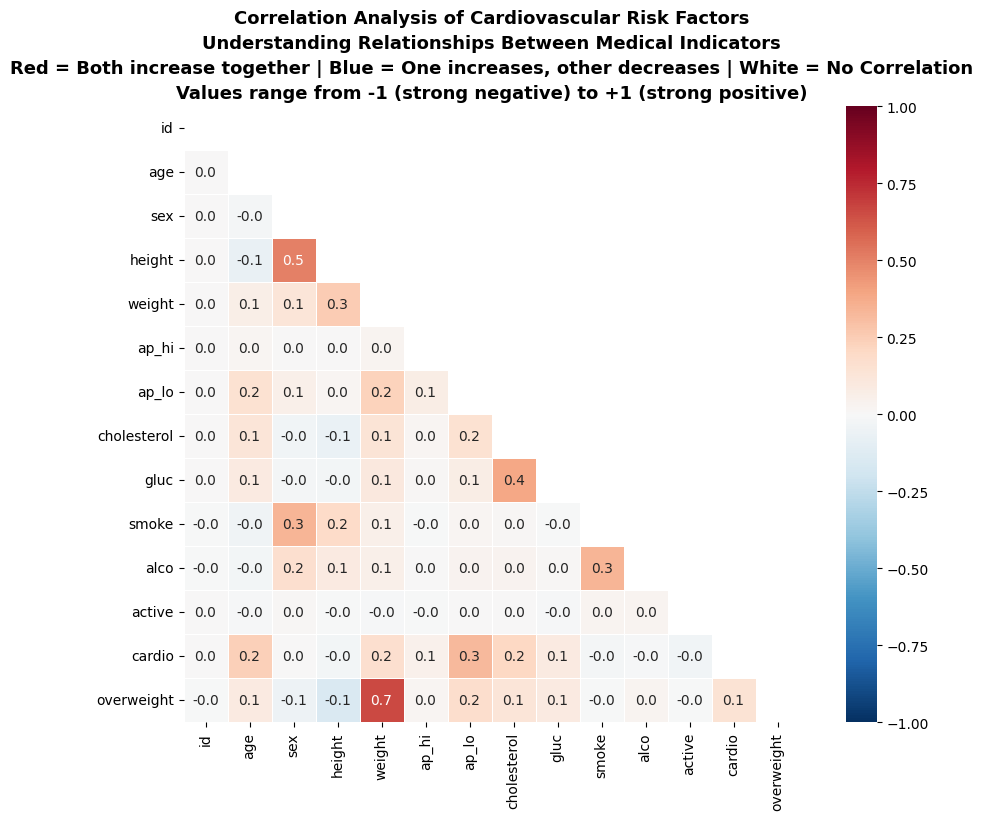

In [7]:
def draw_heat_map():
    # Clean data by filtering out incorrect segments
    df_heat = df[
        (df['ap_lo'] <= df['ap_hi']) &  # diastolic <= systolic
        (df['height'] >= df['height'].quantile(0.025)) &  # height >= 2.5th percentile
        (df['height'] <= df['height'].quantile(0.975)) &  # height <= 97.5th percentile
        (df['weight'] >= df['weight'].quantile(0.025)) &  # weight >= 2.5th percentile
        (df['weight'] <= df['weight'].quantile(0.975))    # weight <= 97.5th percentile
    ]

    # Calculate correlation matrix
    corr = df_heat.corr()

    # Generate mask for upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Set up matplotlib figure
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot heatmap
    sns.heatmap(corr,
                mask=mask,
                annot=True,
                cmap='RdBu_r',
                vmin=-1,
                vmax=1,
                fmt="0.1f",
                linewidths=0.5,
                square=True)

    #main title
    ax.set_title('Correlation Analysis of Cardiovascular Risk Factors\n'
                 'Understanding Relationships Between Medical Indicators\n'
             'Red = Both increase together | Blue = One increases, other decreases | White = No Correlation\n'
             'Values range from -1 (strong negative) to +1 (strong positive)',
             fontsize=13,
             fontweight='bold',
             linespacing=1.5)

    # Save figure
    fig.savefig('heatmap.png')

    return fig

# Call the function
fig_heat = draw_heat_map()
plt.show()

<hr/>
<h2><b>Correlation Heatmap Interpretation</b></h2>

<p style="text-align: justify;">
  The heatmap displays Pearson correlation coefficients between all numerical variables in the dataset. Values range from -1 to +1, where positive values indicate a direct relationship (as one increases, the other increases) and negative values indicate an inverse relationship.
</p>

<p style="text-align: justify;">
  <strong>Key Findings Supporting Categorical Plot Analysis:</strong>
</p>

<p style="text-align: justify;">
  <strong>Cholesterol (r = 0.203):</strong> Shows a positive correlation with cardiovascular disease. This supports the categorical plot observation where the orange bar for cholesterol was approximately double in the disease group (~5,700 vs ~11,900). Elevated cholesterol is clearly associated with higher disease risk.
</p>

<p style="text-align: justify;">
  <strong>Overweight (r = 0.143):</strong> Demonstrates a weak positive correlation with cardiovascular disease. This aligns with the categorical plot where the orange bar was visibly taller in the disease group (~19,100 vs ~24,400). Overweight individuals tend to have a slightly higher risk of cardiovascular disease.
</p>

<p style="text-align: justify;">
  <strong>Glucose (r = 0.088):</strong> Shows a weak positive correlation, consistent with the categorical plot where the orange bar was slightly elevated in the disease group (~4,100 vs ~6,400). Elevated glucose levels are modestly associated with cardiovascular disease.
</p>

<p style="text-align: justify;">
  <strong>Physical Activity (r = -0.037), Smoking (r = -0.020), and Alcohol (r = -0.011):</strong> All show near-zero correlations with cardiovascular disease. This confirms the categorical plot findings where no visible difference was observed between disease and non-disease groups for these factors. These lifestyle factors appear to have minimal association with disease status in this dataset.
</p>

<p style="text-align: justify;">
  <strong>Additional Insights from Heatmap:</strong>
</p>

<p style="text-align: justify;">
  <strong>Diastolic Blood Pressure (ap_lo - r = 0.327):</strong> Shows the strongest correlation with cardiovascular disease among all variables in the heatmap. This suggests that elevated diastolic blood pressure is a major risk factor, even stronger than cholesterol (r = 0.203) and age (r = 0.240). This finding is particularly important because ap_lo was not included in the categorical plot analysis, yet it emerges as the most significant numerical risk factor.
</p>

<p style="text-align: justify;">
  <strong>Age (r = 0.240):</strong> Shows the second strongest correlation with cardiovascular disease among demographic variables. This suggests that older individuals are at higher risk.
</p>

<p style="text-align: justify;">
  <strong>Systolic Blood Pressure (ap_hi - r = 0.051):</strong> Shows a very weak correlation with cardiovascular disease, which is somewhat surprising since blood pressure is typically considered a major risk factor. However, diastolic pressure (ap_lo) appears to be a better predictor in this dataset.
</p>

<p style="text-align: justify;">
  <strong>Weight and Overweight (r = 0.656):</strong> Shows a strong positive correlation, confirming that higher weight directly contributes to overweight classification.
</p>

<p style="text-align: justify;">
  <strong>Cholesterol and Glucose (r = 0.384):</strong> A moderate positive correlation indicates that patients with high cholesterol tend to have elevated glucose as well, suggesting these risk factors often co-occur.
</p>

<p style="text-align: justify;">
  <strong>Smoking and Alcohol (r = 0.341):</strong> Shows a moderate positive correlation, meaning smokers are more likely to consume alcohol. However, neither shows a meaningful correlation with disease status.
</p>

<p style="text-align: justify;">
  <strong>ap_lo and ap_hi (r = 0.073):</strong> Shows a weak correlation between systolic and diastolic blood pressure, suggesting they may capture different aspects of cardiovascular health.
</p>

<p style="text-align: justify;">
  <strong>Conclusion:</strong> The correlation heatmap reveals that <strong>diastolic blood pressure (ap_lo)</strong> has the strongest correlation with cardiovascular disease (r = 0.327), surpassing cholesterol (r = 0.203), age (r = 0.240), and overweight (r = 0.143). This is a critical finding not captured in the categorical plot analysis, which focused only on behavioral and metabolic risk factors. Cholesterol, overweight, and glucose still show meaningful positive correlations, while physical activity, smoking, and alcohol show negligible associations. Additionally, age emerges as an important risk factor warranting further investigation.
</p>

<p style="text-align: justify;">
  <strong>Action Required:</strong> Based on these findings, priority should be given to:
</p>

<p style="text-align: justify;">
  <strong>1. Blood Pressure Management:</strong> Diastolic blood pressure (ap_lo) shows the strongest correlation with disease. Patients with elevated diastolic pressure should be prioritized for hypertension screening and management.
</p>

<p style="text-align: justify;">
  <strong>2. Cholesterol Control:</strong> High cholesterol remains a significant risk factor and should be addressed through dietary modifications and medical intervention.
</p>

<p style="text-align: justify;">
  <strong>3. Weight Management and Glucose Monitoring:</strong> Overweight patients and those with elevated glucose should receive nutritional counseling and regular screening.
</p>

<p style="text-align: justify;">
  <strong>4. Age Consideration:</strong> Older patients should be assessed more carefully, as age shows a meaningful correlation with disease risk.
</p>

<p style="text-align: justify;">
  <strong>5. Routine Preventive Care:</strong> Although physical activity, smoking, and alcohol show weak correlations, standard preventive counseling should continue as part of routine care.
</p>

<p style="text-align: justify;">
  Further statistical testing (e.g., logistic regression) is recommended to confirm these findings and determine exact odds ratios for each risk factor, including diastolic blood pressure.
</p>